In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import time
import matplotlib.colors as mcolors
import signature_pricing_cpp as pricing_cpp
import signature_pricing_py as pricing_py
import signature_core_py as core_py
import signature_core as core_cpp
import processes

plt.rcParams['figure.dpi'] = 100
generate_new_images = False
np.random.seed(0xDEADBEEF)

In [54]:
def generate_blue_to_red(N):
    # Create a colormap from red to blue
    cmap = plt.get_cmap('viridis')
    colors = [mcolors.rgb2hex(cmap(i)[:3]) for i in np.linspace(0, 1, N)]
    return colors

In [55]:
trunc = 6
call_maturity = 1
bs_vol = 0.20
rho = 1.0
S0 = 120
K = 100
sig_bs = core_cpp.from_numpy([np.array(bs_vol)], 2)

a = pricing_cpp.european_call_bs(initial_price=120, strike=100, maturity=1, r=0, sigma=0.2)
t0 = time.time()
b = core_cpp.european_call_sig(S0, call_maturity, K, sig_bs, rho, trunc=4, rk_subdivs=10, integral_subdivs=200, cache=core_cpp.compute_shuffle_cache(4))
runtime = time.time() - t0
print( f"Time: {runtime:.2f} seconds, error: {a - b:.5f}" )

Time: 0.01 seconds, error: -0.00007


Pricing of european options under a mean-reverting geometric brownian motion

In [56]:
# Simulation Parameters
trunc = 2
shuffle_cache = core_cpp.compute_shuffle_cache(trunc)
simulations = 30_000
sim_subdivs = 40      # phi process used for Fourier Pricing
integral_subdivs = 200 # num subdivisions used for integral calculation

# Option Parameters
call_maturity = 1
bs_vol = 0.20
rho = 0.5
S0 = 100
K = 90

# Model parameters
r0    = 0.01 # initial delta
kappa = 0.4  # Mean-reverting speed
etha  = 0.1  # constant volatility
theta = r0   # Target mean for the log difference
alpha = 0.2  # volatility
rho   = 0.2  # correlation between the two brownians (one used for the log price, the other to calculate the price)

In [57]:
# Brownian and time grid
time_grid = np.linspace(start=0.0, stop=1.0, num=100)
model_brownians = processes.generate_brownian(time_grid, n_curves=simulations)
indep_brownians = processes.generate_brownian(time_grid, n_curves=simulations)
log_price_brownian = rho * model_brownians + np.sqrt(1 - rho**2) * indep_brownians

# mrgbm simulation
mrgbms = processes.generate_mrgbm(time_grid.min(), time_grid.max(), model_brownians, r0, kappa, etha, theta, alpha)
log_prices = ( mrgbms[:, :-1] * ( log_price_brownian[:, 1:] - log_price_brownian[:, :-1] ) ).cumsum(axis=1)
mc_processes = S0 * np.concatenate( (np.ones((simulations, 1)), np.exp( log_prices)), axis=1)

# Approximation using signatures
mrgbm_signature_py = processes.compute_mrgbm_signature(r0, kappa, etha, theta, alpha, trunc)
mrgbm_signature_py = core_py.Sig(mrgbm_signature_py.data, dim=2, dtype=np.complex128).truncate(trunc)

mrgbm_signature = core_cpp.from_numpy(mrgbm_signature_py.data)

processes_approx = np.zeros_like(mc_processes)
for i in range(simulations):
    curr_brownian_sig = core_py.signature(np.array([time_grid, model_brownians[i,:].flatten()]), trunc)
    mrgbms_linear_approx = core_py.bracket_with_process(mrgbm_signature_py, curr_brownian_sig)
    log_prices = ( mrgbms_linear_approx[:-1] * ( log_price_brownian[i, 1:] - log_price_brownian[i, :-1] ) ).cumsum()
    sig_process = S0 * np.concatenate( (np.ones(1), np.exp( log_prices)))
    processes_approx[i, :] = sig_process

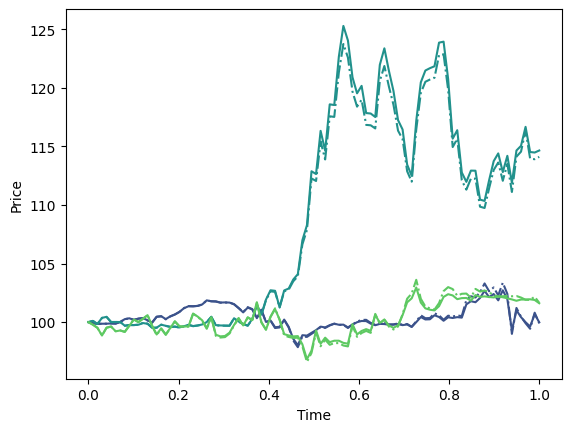

In [58]:
colors = generate_blue_to_red(5)[1:]
for i in range(3):
    plt.plot(time_grid, mc_processes[i, :].T, c=colors[i])
    plt.plot(time_grid, processes_approx[i, :].T, "-.", c=colors[i])
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [59]:
# Pricing with Monte-Carlo simulation
call_price_mc = np.maximum(0, mc_processes[:, -1] - K).mean()
call_price_mc_approx = np.maximum(0, processes_approx[:, -1] - K).mean()

In [66]:
# Pricing with Fourier inversion 
call_price_fi = core_cpp.european_call_sig(S0, time_grid.max(), K, mrgbm_signature, rho, trunc, rk_subdivs=sim_subdivs, integral_subdivs=integral_subdivs, cache=shuffle_cache)
call_price_fi_vr = core_cpp.european_call_sig_vr(S0, time_grid.max(), K, mrgbm_signature, rho, trunc, rk_subdivs=sim_subdivs, integral_subdivs=integral_subdivs, r_bs = 0, vol_bs = alpha, cache=shuffle_cache)

In [67]:
print(f"Monte-Carlo : {call_price_mc} ; Monte-Carlo with signature processes : {call_price_mc_approx}")
print(f"Fourier inversion price : {call_price_fi} ; Fourier inversion w/ V.R. : {call_price_fi_vr}")

Monte-Carlo : 10.307802708141521 ; Monte-Carlo with signature processes : 10.422413566722202
Fourier inversion price : 10.233895462211507 ; Fourier inversion w/ V.R. : 10.273186890030644
